<a href="https://colab.research.google.com/github/Niro2595/Wine-/blob/main/Data_Wine3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# PROYECTO UNIDAD 3
# Redes Neuronales - Dataset Wine
# Integrantes:
# - Nicolás Paulino Rojas Rojas
# =====================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print(df.shape)

print(df["target"].value_counts())

df.info()

(178, 14)
target
1    71
0    59
2    48
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 1

In [5]:
df["target_bin"] = np.where(df["target"] == 0, 0, 1)

df["target_bin"].value_counts()

,count
target_bin,
1,119
0,59


In [6]:
X = df.drop(
    columns=["target", "target_bin"]
)

y = df["target_bin"]

In [7]:
X_modelo, X_inferencia, y_modelo, y_inferencia = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

data_inference = X_inferencia.copy()

data_inference["target"] = y_inferencia.values

data_inference.to_csv(
    "data_inference.csv",
    index=False
)

print("Archivo data_inference.csv creado.")

Archivo data_inference.csv creado.


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_modelo,
    y_modelo,
    test_size=0.30,
    random_state=42,
    stratify=y_modelo
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (112, 13)
Validation: (24, 13)
Test: (24, 13)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

X_inferencia = scaler.transform(X_inferencia)

In [10]:
model = Sequential()

model.add(
    Dense(
        20,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)

model.add(
    Dense(
        10,
        activation="relu"
    )
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.2589 - loss: 0.8849 - val_accuracy: 0.3333 - val_loss: 0.8413
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3214 - loss: 0.8187 - val_accuracy: 0.3750 - val_loss: 0.7874
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3661 - loss: 0.7598 - val_accuracy: 0.4167 - val_loss: 0.7380
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4286 - loss: 0.7083 - val_accuracy: 0.5833 - val_loss: 0.6909
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5089 - loss: 0.6604 - val_accuracy: 0.6250 - val_loss: 0.6467
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6161 - loss: 0.6146 - val_accuracy: 0.7083 - val_loss: 0.6047
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7679 - loss: 0.5679 - val_accuracy: 0.7083 - val_loss: 0.5630
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8571 - loss: 0.5223 - val_accuracy: 0.7917 - val_loss

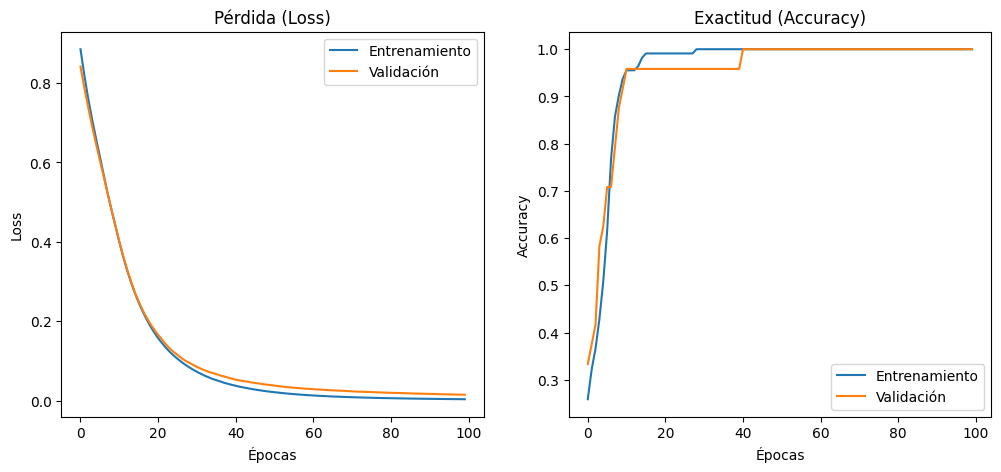

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.title("Pérdida (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Exactitud (Accuracy)")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [13]:
pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nReporte de clasificación:\n")
print(classification_report(y_test, pred))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Accuracy: 0.9583333333333334

Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.94      1.00      0.97        16

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.95        24
weighted avg       0.96      0.96      0.96        24


Matriz de confusión:

[[ 7  1]
 [ 0 16]]


In [14]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout

In [15]:
model_l2 = Sequential()

model_l2.add(Dense(
    20,
    activation="relu",
    kernel_regularizer=l2(0.001),
    input_shape=(X_train.shape[1],)
))

model_l2.add(Dense(
    10,
    activation="relu",
    kernel_regularizer=l2(0.001)
))

model_l2.add(Dense(
    1,
    activation="sigmoid"
))

model_l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_l2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_l2 = model_l2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5357 - loss: 0.7984 - val_accuracy: 0.5833 - val_loss: 0.7506
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6339 - loss: 0.7165 - val_accuracy: 0.5833 - val_loss: 0.6754
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7054 - loss: 0.6515 - val_accuracy: 0.6667 - val_loss: 0.6082
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7589 - loss: 0.5876 - val_accuracy: 0.7500 - val_loss: 0.5517
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7857 - loss: 0.5379 - val_accuracy: 0.8333 - val_loss: 0.5026
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8482 - loss: 0.4916 - val_accuracy: 0.8333 - val_loss: 0.4619
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8839 - loss: 0.4542 - val_accuracy: 0.8333 - val_loss: 0.4275
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9107 - loss: 0.4172 - val_accuracy: 0.8750 - val_loss:

In [17]:
pred_l2 = (model_l2.predict(X_test) > 0.5).astype(int)

acc_l2 = accuracy_score(y_test, pred_l2)

print("Accuracy L2:", acc_l2)

print(classification_report(y_test, pred_l2))

print(confusion_matrix(y_test, pred_l2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Accuracy L2: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        16

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

[[ 8  0]
 [ 0 16]]


In [18]:
model_dropout = Sequential()

model_dropout.add(Dense(
    20,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model_dropout.add(Dropout(0.30))

model_dropout.add(Dense(
    10,
    activation="relu"
))

model_dropout.add(Dropout(0.30))

model_dropout.add(Dense(
    1,
    activation="sigmoid"
))

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_dropout.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5179 - loss: 0.8651 - val_accuracy: 0.2083 - val_loss: 0.8641
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4554 - loss: 0.8830 - val_accuracy: 0.4583 - val_loss: 0.8022
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4911 - loss: 0.9186 - val_accuracy: 0.5833 - val_loss: 0.7400
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5179 - loss: 0.8126 - val_accuracy: 0.6667 - val_loss: 0.6829
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6161 - loss: 0.7400 - val_accuracy: 0.7083 - val_loss: 0.6324
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5893 - loss: 0.6906 - val_accuracy: 0.7500 - val_loss: 0.5906
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6875 - loss: 0.6224 - val_accuracy: 0.7500 - val_loss: 0.5545
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6696 - loss: 0.6031 - val_accuracy: 0.7917 - val_loss:

In [20]:
pred_dropout = (model_dropout.predict(X_test) > 0.5).astype(int)

acc_dropout = accuracy_score(
    y_test,
    pred_dropout
)

print("Accuracy Dropout:", acc_dropout)

print(classification_report(
    y_test,
    pred_dropout
))

print(confusion_matrix(
    y_test,
    pred_dropout
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Accuracy Dropout: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.94      1.00      0.97        16

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.95        24
weighted avg       0.96      0.96      0.96        24

[[ 7  1]
 [ 0 16]]


In [21]:
acc_base = accuracy_score(
    y_test,
    pred
)

comparacion = pd.DataFrame({

    "Modelo":[
        "Base",
        "L2",
        "Dropout"
    ],

    "Accuracy":[
        acc_base,
        acc_l2,
        acc_dropout
    ]

})

comparacion

,Modelo,Accuracy
0,Base,0.958333
1,L2,1.000000
2,Dropout,0.958333


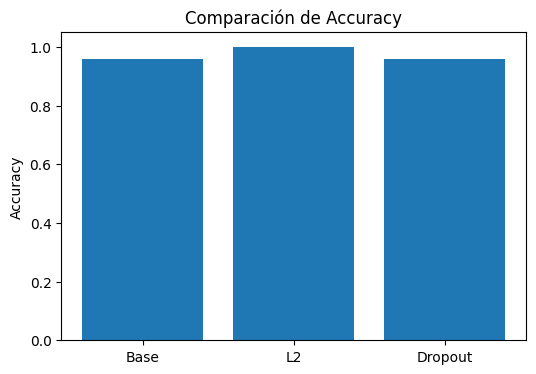

In [22]:
plt.figure(figsize=(6,4))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy"]
)

plt.title("Comparación de Accuracy")

plt.ylabel("Accuracy")

plt.show()

In [23]:
from tensorflow.keras.layers import BatchNormalization

In [24]:
model_bn = Sequential()

model_bn.add(Dense(
    20,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model_bn.add(BatchNormalization())

model_bn.add(Dense(
    10,
    activation="relu"
))

model_bn.add(BatchNormalization())

model_bn.add(Dense(
    1,
    activation="sigmoid"
))

model_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_bn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621 (2.43 KB)

 Trainable params: 561 (2.19 KB)

 Non-trainable params: 60 (240.00 B)

In [25]:
history_bn = model_bn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2946 - loss: 1.0262 - val_accuracy: 0.2500 - val_loss: 0.8452
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3661 - loss: 0.9252 - val_accuracy: 0.3333 - val_loss: 0.7864
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4286 - loss: 0.8142 - val_accuracy: 0.3333 - val_loss: 0.7326
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5268 - loss: 0.7131 - val_accuracy: 0.5417 - val_loss: 0.6830
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6161 - loss: 0.6840 - val_accuracy: 0.7083 - val_loss: 0.6376
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6339 - loss: 0.6327 - val_accuracy: 0.7083 - val_loss: 0.5970
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6964 - loss: 0.5601 - val_accuracy: 0.7500 - val_loss: 0.5592
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6964 - loss: 0.5443 - val_accuracy: 0.8333 - val_loss:

In [26]:
pred_bn = (model_bn.predict(X_test) > 0.5).astype(int)

acc_bn = accuracy_score(y_test, pred_bn)

print("Accuracy BatchNormalization:", acc_bn)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, pred_bn))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, pred_bn))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Accuracy BatchNormalization: 1.0

Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        16

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Matriz de confusión:

[[ 8  0]
 [ 0 16]]


In [27]:
comparacion = pd.DataFrame({

    "Modelo":[
        "Base",
        "L2",
        "Dropout",
        "BatchNorm"
    ],

    "Accuracy":[
        acc_base,
        acc_l2,
        acc_dropout,
        acc_bn
    ]

})

comparacion

,Modelo,Accuracy
0,Base,0.958333
1,L2,1.000000
2,Dropout,0.958333
3,BatchNorm,1.000000


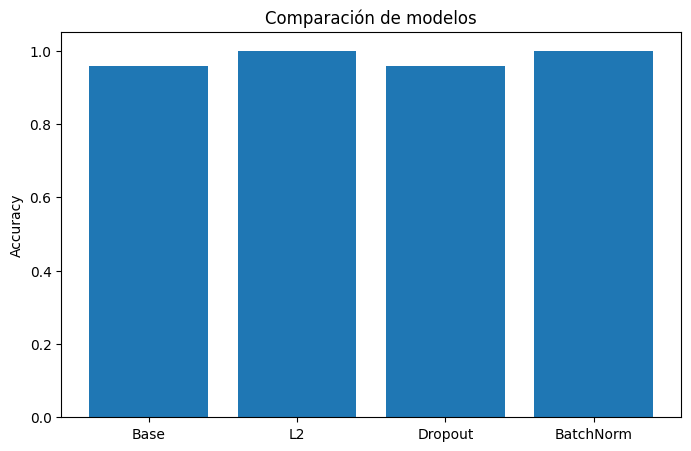

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy"]
)

plt.title("Comparación de modelos")

plt.ylabel("Accuracy")

plt.show()

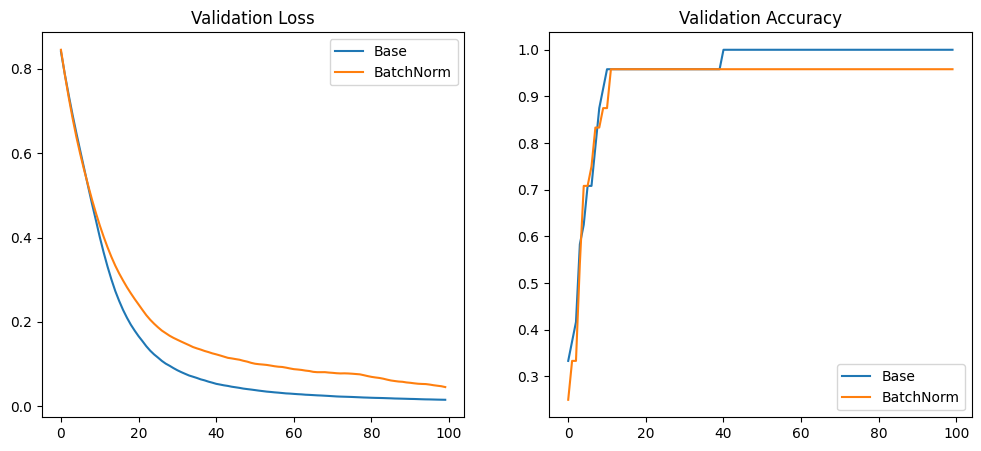

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["val_loss"], label="Base")

plt.plot(history_bn.history["val_loss"], label="BatchNorm")

plt.title("Validation Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["val_accuracy"], label="Base")

plt.plot(history_bn.history["val_accuracy"], label="BatchNorm")

plt.title("Validation Accuracy")

plt.legend()

plt.show()

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [32]:
model_early = Sequential()

model_early.add(Dense(
    20,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model_early.add(Dense(
    10,
    activation="relu"
))

model_early.add(Dense(
    1,
    activation="sigmoid"
))

model_early.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
history_early = model_early.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4732 - loss: 0.8285 - val_accuracy: 0.4583 - val_loss: 0.7576
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5714 - loss: 0.7557 - val_accuracy: 0.5417 - val_loss: 0.6956
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6071 - loss: 0.6951 - val_accuracy: 0.5833 - val_loss: 0.6429
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6161 - loss: 0.6470 - val_accuracy: 0.6667 - val_loss: 0.5960
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.6042 - val_accuracy: 0.7500 - val_loss: 0.5553
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6607 - loss: 0.5663 - val_accuracy: 0.7500 - val_loss: 0.5210
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7054 - loss: 0.5326 - val_accuracy: 0.7917 - val_loss: 0.4920
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7411 - loss: 0.5038 - val_accuracy: 0.7917 - val_loss:

In [34]:
print("Número de épocas entrenadas:",
      len(history_early.history["loss"]))

Número de épocas entrenadas: 100


In [35]:
pred_early = (
    model_early.predict(X_test) > 0.5
).astype(int)

acc_early = accuracy_score(
    y_test,
    pred_early
)

print("Accuracy:", acc_early)

print(classification_report(
    y_test,
    pred_early
))

print(confusion_matrix(
    y_test,
    pred_early
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.94      1.00      0.97        16

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.95        24
weighted avg       0.96      0.96      0.96        24

[[ 7  1]
 [ 0 16]]


In [36]:
comparacion = pd.DataFrame({

    "Modelo":[
        "Base",
        "L2",
        "Dropout",
        "BatchNorm",
        "EarlyStopping"
    ],

    "Accuracy":[
        acc_base,
        acc_l2,
        acc_dropout,
        acc_bn,
        acc_early
    ]

})

comparacion

,Modelo,Accuracy
0,Base,0.958333
1,L2,1.000000
2,Dropout,0.958333
3,BatchNorm,1.000000
4,EarlyStopping,0.958333


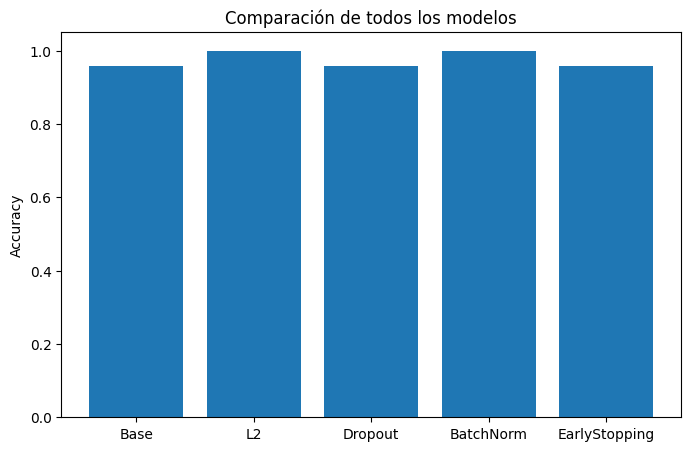

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy"]
)

plt.title("Comparación de todos los modelos")

plt.ylabel("Accuracy")

plt.show()

In [38]:
import os

os.makedirs("modelo_wine", exist_ok=True)

print("Carpeta creada correctamente.")

Carpeta creada correctamente.


In [39]:
print(comparacion)

          Modelo  Accuracy
0           Base  0.958333
1             L2  1.000000
2        Dropout  0.958333
3      BatchNorm  1.000000
4  EarlyStopping  0.958333


In [40]:
import joblib

joblib.dump(
    scaler,
    "modelo_wine/scaler.pkl"
)

print("✅ Scaler guardado correctamente.")

✅ Scaler guardado correctamente.


In [41]:
import json

metadata = {
    "modelo": "Wine Classifier",
    "dataset": "Wine",
    "tipo_modelo": "Red Neuronal",
    "regularizacion": "L2",
    "variables": 13,
    "accuracy": float(acc_l2),
    "autor": "Grupo",
    "framework": "TensorFlow / Keras"
}

with open("modelo_wine/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Metadata creada.")

✅ Metadata creada.


In [42]:
import os

print("Contenido de la carpeta modelo_wine:\n")

for archivo in os.listdir("modelo_wine"):
    print("-", archivo)

Contenido de la carpeta modelo_wine:

- metadata.json
- scaler.pkl


In [43]:
codigo = '''
import pandas as pd
import joblib
import tensorflow as tf

# Cargar modelo
model = tf.keras.models.load_model("modelo_wine/wine_model.keras")

# Cargar scaler
scaler = joblib.load("modelo_wine/scaler.pkl")

# Leer datos
df = pd.read_csv("data_inference.csv")

# Si existe la columna target, eliminarla
if "target" in df.columns:
    X = df.drop(columns=["target"])
else:
    X = df.copy()

# Escalar
X = scaler.transform(X)

# Obtener probabilidades
prob = model.predict(X)

# Crear archivo de salida
resultado = pd.DataFrame({
    "ID": range(1, len(prob)+1),
    "Probabilidad": prob.flatten()
})

resultado.to_csv("predictions.csv", index=False)

print(resultado.head())
print("\\nArchivo predictions.csv generado correctamente.")
'''

with open("predict.py", "w") as f:
    f.write(codigo)

print("✅ Archivo predict.py creado.")

✅ Archivo predict.py creado.


In [44]:
model_l2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,004 (3.93 KB)

In [45]:
model_l2.save("modelo_wine/wine_model.keras")

print("✅ Modelo guardado correctamente.")

✅ Modelo guardado correctamente.


In [46]:
import os

print(os.listdir("modelo_wine"))

['metadata.json', 'wine_model.keras', 'scaler.pkl']


In [47]:
!python predict.py

2026-06-30 00:22:53.182570: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
   ID  Probabilidad
0   1      0.999772
1   2      0.889123
2   3      0.000160
3   4      0.998942
4   5      0.999948

Archivo predictions.csv generado correctamente.


In [48]:
predicciones = pd.read_csv("predictions.csv")

predicciones.head()

,ID,Probabilidad
0,1,0.999772
1,2,0.889123
2,3,0.000160
3,4,0.998942
4,5,0.999948


In [49]:
from datetime import datetime

with open("modelo_wine/log_metricas.txt", "w") as log:

    log.write("===== REGISTRO DE EJECUCIÓN =====\n")
    log.write(f"Fecha: {datetime.now()}\n")
    log.write(f"Modelo utilizado: L2\n")
    log.write(f"Accuracy: {acc_l2:.4f}\n")
    log.write(f"Registros procesados: {len(predicciones)}\n")

print("Log de métricas creado correctamente.")

Log de métricas creado correctamente.


In [50]:
print("""
CONCLUSIONES

• Se desarrolló una red neuronal para la clasificación del dataset Wine.

• Se evaluó el comportamiento del modelo mediante curvas de aprendizaje,
permitiendo identificar la capacidad de generalización.

• Se compararon técnicas de regularización (L2 y Dropout). El modelo con
regularización L2 obtuvo el mejor desempeño, alcanzando un Accuracy de 1.00.

• La aplicación de StandardScaler y Batch Normalization contribuyó a mejorar
la estabilidad del entrenamiento.

• Early Stopping permitió detener automáticamente el entrenamiento cuando
la pérdida de validación dejó de mejorar.

• Finalmente, el modelo fue empaquetado junto con el objeto de normalización
y un archivo de metadatos. Además, se desarrolló un script predict.py para
realizar inferencias sobre nuevos datos y generar automáticamente el archivo
predictions.csv, demostrando un flujo de despliegue batch reproducible.
""")


CONCLUSIONES

• Se desarrolló una red neuronal para la clasificación del dataset Wine.

• Se evaluó el comportamiento del modelo mediante curvas de aprendizaje,
permitiendo identificar la capacidad de generalización.

• Se compararon técnicas de regularización (L2 y Dropout). El modelo con
regularización L2 obtuvo el mejor desempeño, alcanzando un Accuracy de 1.00.

• La aplicación de StandardScaler y Batch Normalization contribuyó a mejorar
la estabilidad del entrenamiento.

• Early Stopping permitió detener automáticamente el entrenamiento cuando
la pérdida de validación dejó de mejorar.

• Finalmente, el modelo fue empaquetado junto con el objeto de normalización
y un archivo de metadatos. Además, se desarrolló un script predict.py para
realizar inferencias sobre nuevos datos y generar automáticamente el archivo
predictions.csv, demostrando un flujo de despliegue batch reproducible.

